In [ ]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

# Настройки для красивых графиков
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

DATA_DIR = "./Data/"

# Смотрим на данные

In [2]:
car_data = pd.read_csv(DATA_DIR + "car_data.csv", parse_dates=["Date"])
sneakers_data = pd.read_csv(DATA_DIR + "sneakers_data.csv", parse_dates=["Date"])

print("car_data:")
print(f"   Размер: {car_data.shape}")
print(f"   Период: {car_data['Date'].min().date()} — {car_data['Date'].max().date()}")
print(f"   Столбцы: {list(car_data.columns)}")

print("sneakers_data:")
print(f"   Размер: {sneakers_data.shape}")
print(
    f"   Период: {sneakers_data['Date'].min().date()} — {sneakers_data['Date'].max().date()}"
)
print(f"   Столбцы: {list(sneakers_data.columns)}")

car_data:
   Размер: (1485, 5)
   Период: 2021-01-04 — 2026-09-30
   Столбцы: ['Date', 'Volkswagen', 'Renault', 'Li Auto', 'NIO']
sneakers_data:
   Размер: (2001, 3)
   Период: 2019-01-02 — 2026-09-30
   Столбцы: ['Date', 'Nike', 'Puma']


In [3]:
car_duplicates = car_data["Date"].duplicated().sum()
sneakers_duplicates = sneakers_data["Date"].duplicated().sum()
print(f"car_data: {car_duplicates} дубликатов дат")
print(f"sneakers_data: {sneakers_duplicates} дубликатов дат")

car_data: 0 дубликатов дат
sneakers_data: 0 дубликатов дат


In [4]:
car_missing = car_data.isnull().sum()
sneakers_missing = sneakers_data.isnull().sum()

print("car_data - пропуски по столбцам:")
print(car_missing)
print(
    f"Всего пропусков: {car_missing.sum()} ({car_missing.sum() / car_data.size * 100:.2f}%)"
)

print("sneakers_data - пропуски по столбцам:")
print(sneakers_missing)
print(
    f"Всего пропусков: {sneakers_missing.sum()} ({sneakers_missing.sum() / sneakers_data.size * 100:.2f}%)"
)

car_data - пропуски по столбцам:
Date           0
Volkswagen    43
Renault       43
Li Auto       13
NIO           20
dtype: int64
Всего пропусков: 119 (1.60%)
sneakers_data - пропуски по столбцам:
Date     0
Nike    54
Puma    31
dtype: int64
Всего пропусков: 85 (1.42%)


In [5]:
print("car_data:")
display(car_data.describe())

print("sneakers_data:")
display(sneakers_data.describe())

car_data:


,Date,Volkswagen,Renault,Li Auto,NIO
count,1485,1442.000000,1442.000000,1472.000000,1465.000000
mean,2023-11-15 20:11:09.090909,25.703578,14.585430,31.286236,95.379207
min,2021-01-04 00:00:00,11.230000,3.140000,18.039293,69.940002
25%,2022-06-09 00:00:00,20.317500,4.900000,27.446255,85.195946
50%,2023-11-14 00:00:00,25.370001,7.700000,30.345371,92.917633
75%,2025-04-24 00:00:00,30.400000,19.860001,34.163579,99.054688
max,2026-09-30 00:00:00,46.650002,62.840000,47.844357,148.802689
std,NaN,7.033653,14.119375,6.137693,15.200584


sneakers_data:


,Date,Nike,Puma
count,2001,1947.000000,1970.000000
mean,2022-11-15 17:14:07.376311,91.179403,52.812684
min,2019-01-02 00:00:00,35.400002,15.455000
25%,2020-12-08 00:00:00,72.651691,38.340607
50%,2022-11-15 00:00:00,88.327148,51.258928
75%,2024-10-22 00:00:00,111.037971,65.102556
max,2026-09-30 00:00:00,161.967758,106.701408
std,NaN,27.733059,21.947271


In [6]:
# Проверяем, есть ли данные в выходные
car_data_dow = car_data["Date"].dt.dayofweek  # 0=Пн, 6=Вс
sneakers_data_dow = sneakers_data["Date"].dt.dayofweek

car_weekends = car_data[car_data_dow >= 5]
sneakers_weekends = sneakers_data[sneakers_data_dow >= 5]

print(f"car_data - записей в выходные: {len(car_weekends)}")
print(f"sneakers_data - записей в выходные: {len(sneakers_weekends)}")

car_data - записей в выходные: 0
sneakers_data - записей в выходные: 0


In [7]:
# Проверяем разрывы в датах (больше 1 дня)
car_data_sorted = car_data.sort_values("Date")
sneakers_data_sorted = sneakers_data.sort_values("Date")

car_gaps = car_data_sorted["Date"].diff().dt.days
sneakers_gaps = sneakers_data_sorted["Date"].diff().dt.days

print(f"\ncar_data - максимальный разрыв между датами: {car_gaps.max()} дней")
print(f"sneakers_data - максимальный разрыв между датами: {sneakers_gaps.max()} дней")


car_data - максимальный разрыв между датами: 4.0 дней
sneakers_data - максимальный разрыв между датами: 4.0 дней


In [8]:
# Показываем большие разрывы
big_gap = 3
large_gaps_car = car_data_sorted[car_gaps > big_gap]
large_gaps_sneakers = sneakers_data_sorted[sneakers_gaps > big_gap]

if len(large_gaps_car) > 0:
    print(f"Большие разрывы в car_data: (> {big_gap} дней)")
    for idx, row in large_gaps_car.iterrows():
        prev_date = car_data_sorted.loc[idx - 1, "Date"] if idx > 0 else None
        if prev_date is not None:
            print(
                f"   {prev_date.date()} → {row['Date'].date()} ({car_gaps.loc[idx]} дней)"
            )

if len(large_gaps_sneakers) > 0:
    print(f"Большие разрывы в sneakers_data: (> {big_gap} дней)")
    for idx, row in large_gaps_sneakers.iterrows():
        prev_date = sneakers_data_sorted.loc[idx - 1, "Date"] if idx > 0 else None
        if prev_date is not None:
            print(
                f"   {prev_date.date()} → {row['Date'].date()} ({sneakers_gaps.loc[idx]} дней)"
            )


Большие разрывы в car_data: (> 3 дней)
   2021-04-01 → 2021-04-05 (4.0 дней)
   2022-04-14 → 2022-04-18 (4.0 дней)
   2022-12-23 → 2022-12-27 (4.0 дней)
   2023-04-06 → 2023-04-10 (4.0 дней)
   2023-12-22 → 2023-12-26 (4.0 дней)
   2023-12-29 → 2024-01-02 (4.0 дней)
   2024-03-28 → 2024-04-01 (4.0 дней)
   2025-04-17 → 2025-04-21 (4.0 дней)
   2026-04-02 → 2026-04-06 (4.0 дней)
Большие разрывы в sneakers_data: (> 3 дней)
   2019-04-18 → 2019-04-22 (4.0 дней)
   2020-04-09 → 2020-04-13 (4.0 дней)
   2020-12-24 → 2020-12-28 (4.0 дней)
   2020-12-31 → 2021-01-04 (4.0 дней)
   2021-04-01 → 2021-04-05 (4.0 дней)
   2021-12-23 → 2021-12-27 (4.0 дней)
   2022-04-14 → 2022-04-18 (4.0 дней)
   2022-12-23 → 2022-12-27 (4.0 дней)
   2023-04-06 → 2023-04-10 (4.0 дней)
   2023-12-22 → 2023-12-26 (4.0 дней)
   2023-12-29 → 2024-01-02 (4.0 дней)
   2024-03-28 → 2024-04-01 (4.0 дней)
   2025-04-17 → 2025-04-21 (4.0 дней)
   2026-04-02 → 2026-04-06 (4.0 дней)


Я глянул все пропуски связаны с праздинками, в эти дни биржка не работала, поэтому по идее это норм, ща в следующем пункте закроем их

Тут делаем две вещи:
1. Приводим к регулярной сетке (Понедельник-Пятница), добавив в сетку празники, но не выходные
2. Заполняем  пропуски ffil-ом (это заполнение предыдущем значением)

In [9]:
# Ставим дату на индекс. По хорошему это надо было сделать в самом начале, но там уже код, который ожидает что дата - это колонка
# TODO добавить вот эти две строки в начало и переписать квесь код выше, где используется колонка Date
car_data = car_data.set_index("Date").sort_index()
sneakers_data = sneakers_data.set_index("Date").sort_index()

In [10]:
car_business_days = pd.date_range(
    start=car_data.index.min(),
    end=car_data.index.max(),
    freq="B",  # 'B' = business days (понедельник-пятница)
)

sneakers_business_days = pd.date_range(
    start=sneakers_data.index.min(), end=sneakers_data.index.max(), freq="B"
)
# ffill заполняет пропуски последним известным значением сверху
car_data = car_data.reindex(car_business_days).ffill()
sneakers_data = sneakers_data.reindex(sneakers_business_days).ffill()

print(f"car_data пропусков осталось: {car_data.isnull().sum().sum()}")
print(f"sneakers_data пропусков осталось: {sneakers_data.isnull().sum().sum()}")

sample = car_data.loc["2021-03-30":"2021-04-07", "Volkswagen"]

print("Фрагмент данных Volkswagen (30 марта - 7 апреля 2021):")
print(sample)


car_data пропусков осталось: 0
sneakers_data пропусков осталось: 0
Фрагмент данных Volkswagen (30 марта - 7 апреля 2021):
2021-03-30    23.080000
2021-03-31    25.000000
2021-04-01    25.250000
2021-04-02    25.250000
2021-04-05    24.940001
2021-04-06    25.530001
2021-04-07    22.230000
Freq: B, Name: Volkswagen, dtype: float64


In [11]:
for df_name, df in [("car_data", car_data), ("sneakers_data", sneakers_data)]:
    print(df_name)
    for col in df.columns[1:]:
        if df[col].notna().sum() > 1:
            # Дневная доходность
            returns = df[col].pct_change() * 100

            # Статистика
            mean_ret = returns.mean()
            std_ret = returns.std()
            max_ret = returns.max()
            min_ret = returns.min()
            # Выбросы (> 3 sigma)
            outliers = returns[abs(returns - mean_ret) > 3 * std_ret]

            print(f"\n  {col}:")
            print(f"    Средняя доходность: {mean_ret:.3f}%")
            print(f"    Стандартное отклонение: {std_ret:.3f}%")
            print(f"    Макс. рост: {max_ret:.2f}%")
            print(f"    Макс. падение: {min_ret:.2f}%")
            print(f"    Выбросов (> 3σ): {len(outliers)}")

            if len(outliers) > 0:
                print(" Даты выбросов:")
                for date in outliers.index[:5]:  # Показываем первые 5
                    print(f"      {date.date()}: {returns.loc[date]:.2f}%")

car_data

  Renault:
    Средняя доходность: -0.090%
    Стандартное отклонение: 4.354%
    Макс. рост: 25.59%
    Макс. падение: -17.07%
    Выбросов (> 3σ): 16
 Даты выбросов:
      2021-03-09: 17.44%
      2021-12-30: 14.76%
      2022-01-31: 17.27%
      2022-03-16: 25.59%
      2022-05-05: -15.17%

  Li Auto:
    Средняя доходность: 0.015%
    Стандартное отклонение: 2.263%
    Макс. рост: 11.68%
    Макс. падение: -18.47%
    Выбросов (> 3σ): 18
 Даты выбросов:
      2021-06-11: 7.05%
      2021-11-26: -7.80%
      2022-02-24: -9.07%
      2022-03-01: -11.23%
      2022-03-09: 11.12%

  NIO:
    Средняя доходность: 0.002%
    Стандартное отклонение: 1.884%
    Макс. рост: 11.04%
    Макс. падение: -7.62%
    Выбросов (> 3σ): 23
 Даты выбросов:
      2021-03-16: 6.71%
      2021-03-17: 11.04%
      2021-03-22: 7.29%
      2021-07-09: 5.91%
      2021-12-07: 8.63%
sneakers_data

  Puma:
    Средняя доходность: 0.007%
    Стандартное отклонение: 2.628%
    Макс. рост: 18.91%
    Мак

# Определяем целевую переменную и проверяем её на стационарность

In [12]:
# Формируем таргет
# TODO выбрать, что предсказывать будем. Пока оставлю сырые цены
# Также можно ещё вариантов накинуть, например вторые разности

# Вариант 1: Сырые цены (просто копируем с припиской _target)
for col in car_data.columns:
    car_data[f"{col}_target"] = car_data[col]

for col in sneakers_data.columns:
    sneakers_data[f"{col}_target"] = sneakers_data[col]


# # Вариант 2: Логарифмические доходности
# for col in car_data.columns:
#     car_data[f'{col}_target'] = np.log(car_data[col]) - np.log(car_data[col].shift(1))

# for col in sneakers_data.columns:
#     sneakers_data[f'{col}_target'] = np.log(sneakers_data[col]) - np.log(sneakers_data[col].shift(1))


# # Вариант 3: Дифференцированные цены
# for col in car_data.columns:
#     car_data[f'{col}_target'] = car_data[col].diff()

# for col in sneakers_data.columns:
#     sneakers_data[f'{col}_target'] = sneakers_data[col].diff()

In [13]:
# Проверяем на стационарность

car_target_cols = [c for c in car_data.columns if c.endswith("_target")]
sneakers_target_cols = [c for c in sneakers_data.columns if c.endswith("_target")]


def run_adf_test(series, name):
    """Тест Augmented Dickey-Fuller.
    H₀: ряд нестационарен (имеет единичный корень)
    Если p-value < 0.05 → отвергаем H₀ → ряд стационарен
    """
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "Тикер": name,
        "ADF статистика": result[0],
        "p-value": result[1],
        "Лагов использовано": result[2],
        "Крит. знач. 5%": result[4]["5%"],
        "Стационарен?": "ДА" if result[1] < 0.05 else "НЕТ",
    }


def run_kpss_test(series, name):
    """Тест KPSS.
    H₀: ряд стационарен
    Если p-value < 0.05 → отвергаем H₀ → ряд нестационарен
    """
    # regression='ct' — с трендом, 'c' — только константа
    # Для цен с явным трендом используем 'ct'
    try:
        result = kpss(series.dropna(), regression="ct", nlags="auto")
    except Exception:
        result = kpss(series.dropna(), regression="c", nlags="auto")

    return {
        "Тикер": name,
        "KPSS статистика": result[0],
        "p-value": result[1],
        "Лагов использовано": result[2],
        "Крит. знач. 5%": result[3]["5%"],
        "Стационарен?": "ДА" if result[1] >= 0.05 else "НЕТ",
    }


In [14]:
car_adf_results = []
car_kpss_results = []

for col in car_target_cols:
    series = car_data[col]
    ticker_name = col.replace("_target", "")

    car_adf_results.append(run_adf_test(series, ticker_name))
    car_kpss_results.append(run_kpss_test(series, ticker_name))

car_adf_df = pd.DataFrame(car_adf_results)
car_kpss_df = pd.DataFrame(car_kpss_results)

print("\n📋 ADF тест (H₀: ряд нестационарен):")
print(car_adf_df.to_string(index=False))

print("\n📋 KPSS тест (H₀: ряд стационарен):")
print(car_kpss_df.to_string(index=False))


📋 ADF тест (H₀: ряд нестационарен):
     Тикер  ADF статистика  p-value  Лагов использовано  Крит. знач. 5% Стационарен?
Volkswagen       -2.579120 0.097390                   0       -2.863473          НЕТ
   Renault       -3.533706 0.007162                  22       -2.863501           ДА
   Li Auto       -2.064906 0.258858                   0       -2.863473          НЕТ
       NIO       -2.156473 0.222420                   3       -2.863477          НЕТ

📋 KPSS тест (H₀: ряд стационарен):
     Тикер  KPSS статистика  p-value  Лагов использовано  Крит. знач. 5% Стационарен?
Volkswagen         0.449634     0.01                  25           0.146          НЕТ
   Renault         1.199108     0.01                  25           0.146          НЕТ
   Li Auto         0.633951     0.01                  25           0.146          НЕТ
       NIO         0.399295     0.01                  25           0.146          НЕТ


Кто бы мог подумать, ряд нестационарен

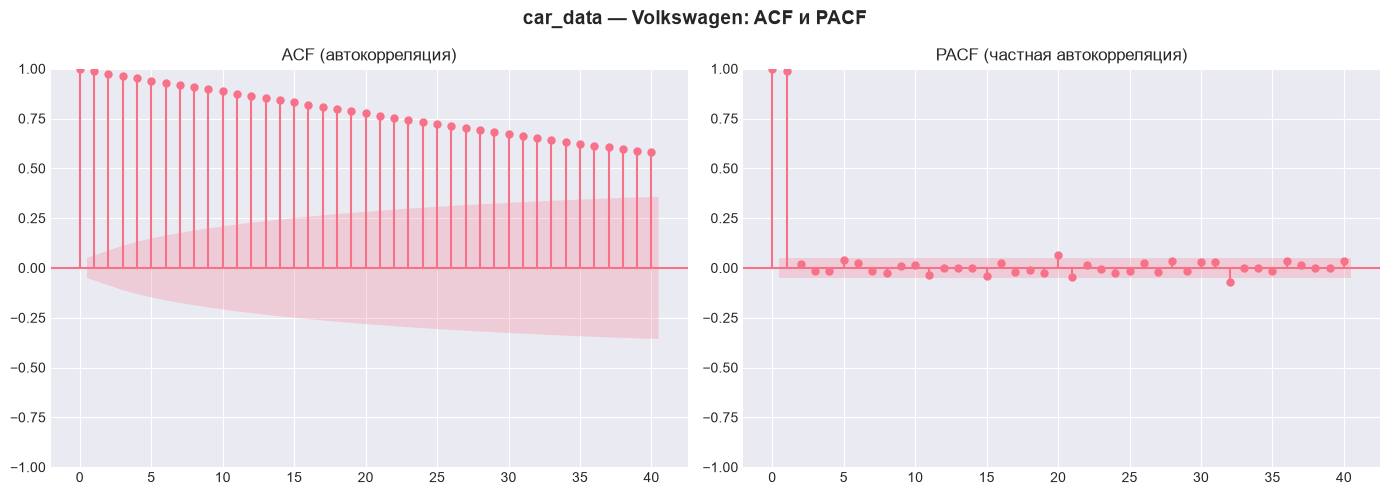

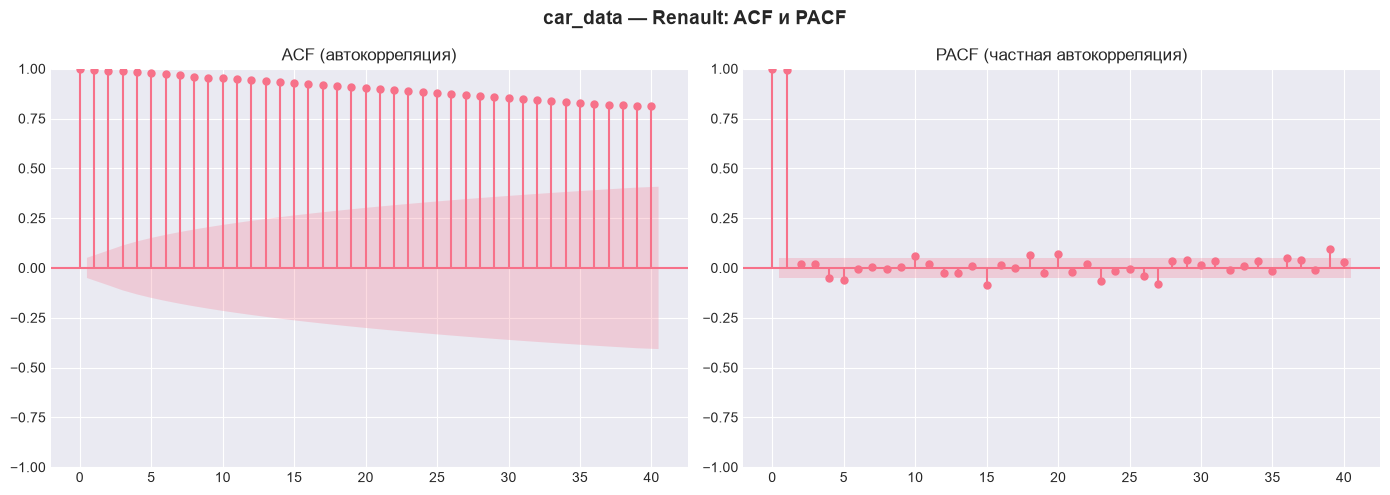

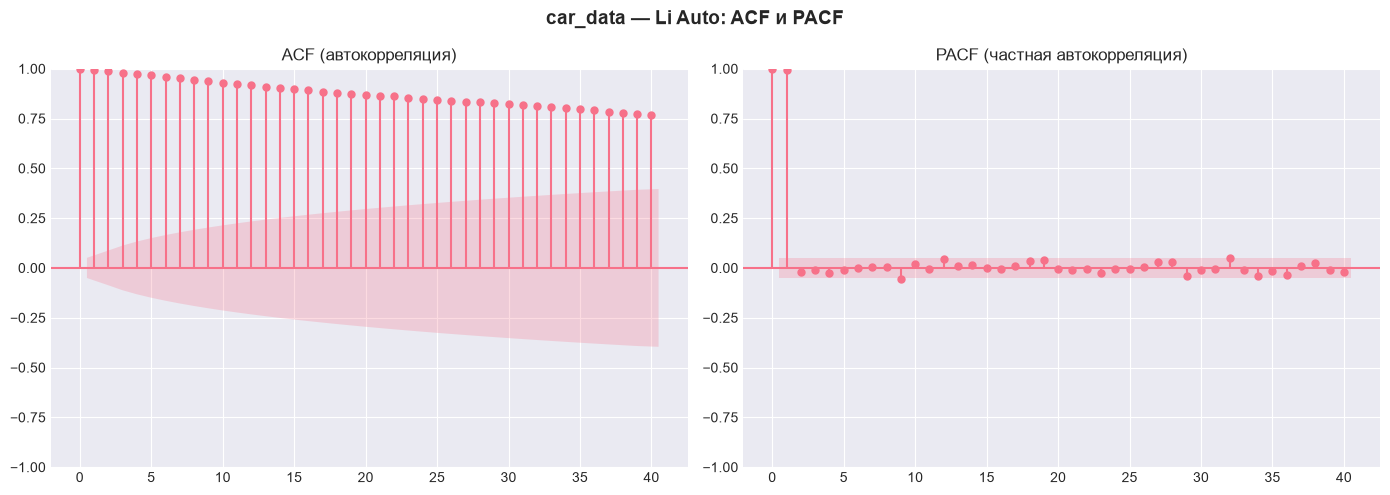

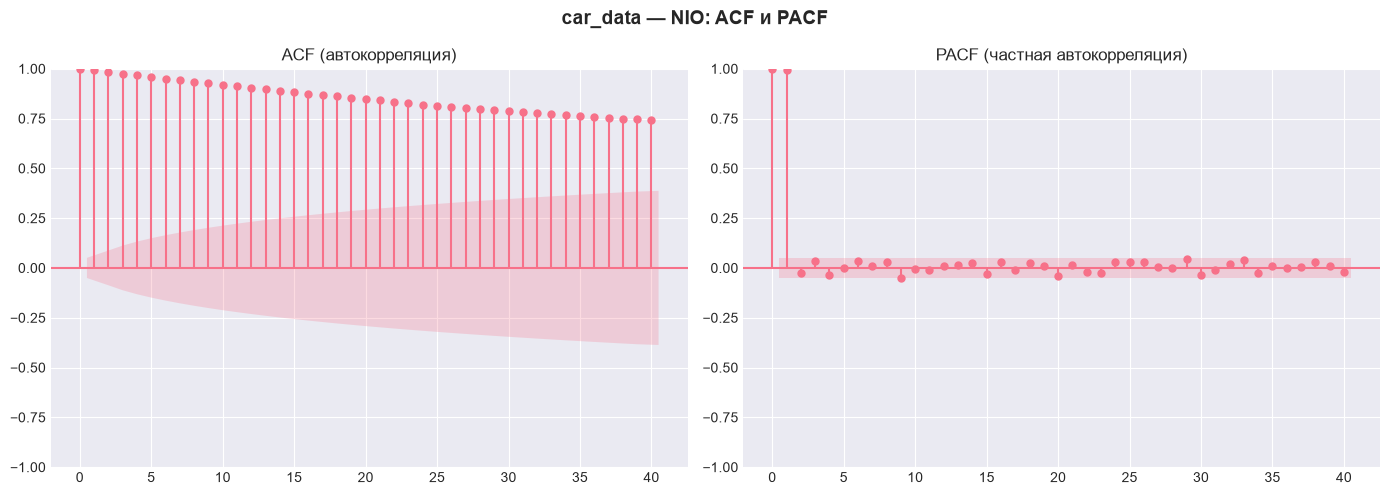

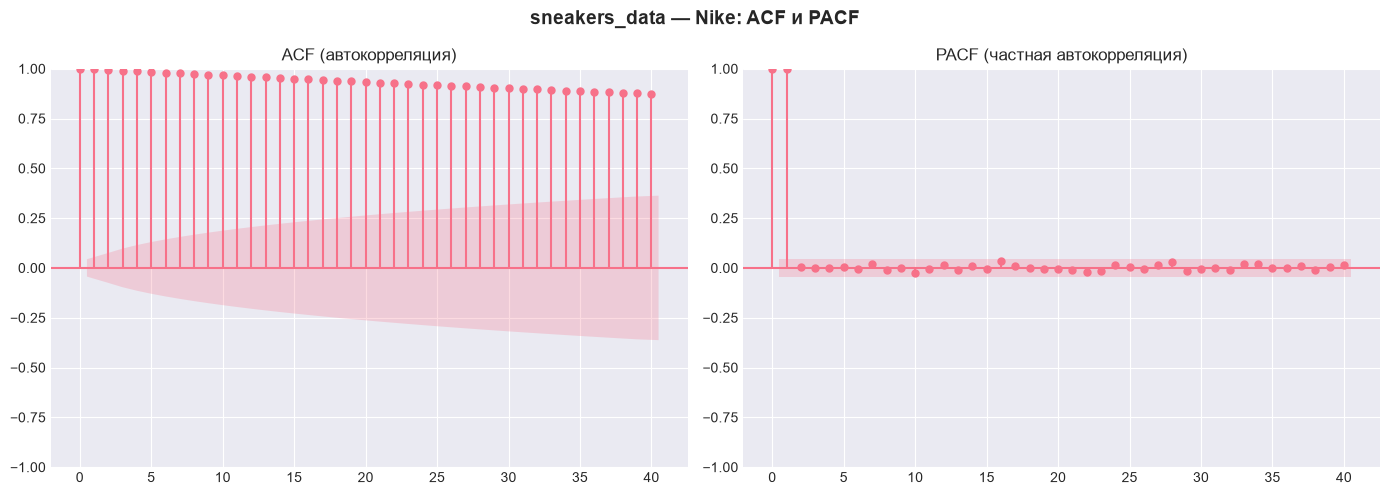

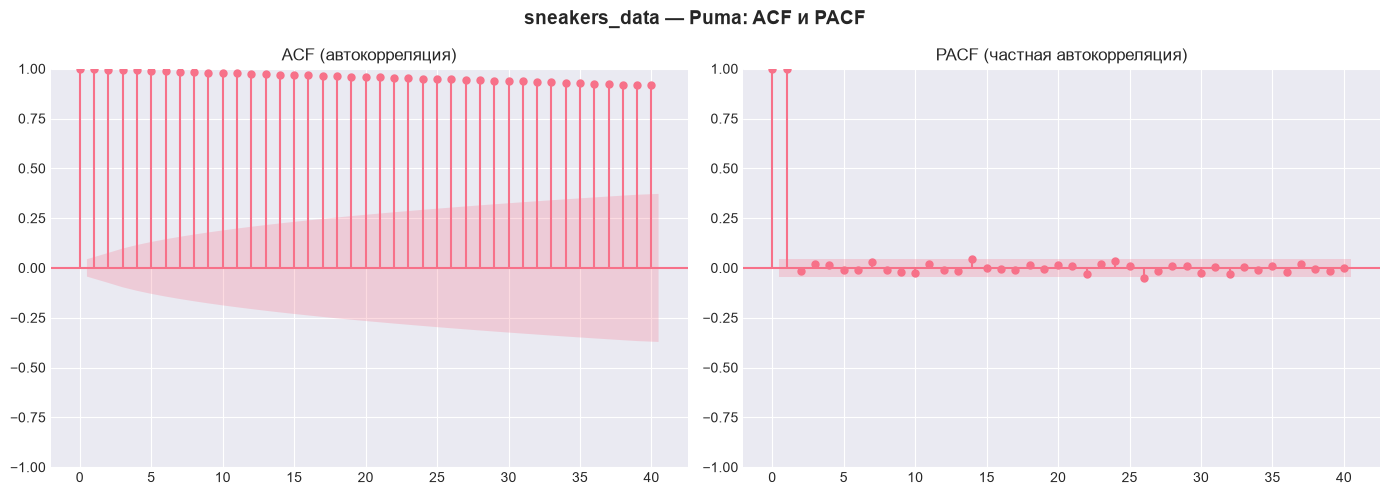

In [15]:
# Отрисовываем графики корр функций
def plot_acf_pacf(df, col, ticker_name, dataset_name):
    """Построение ACF и PACF графиков."""
    series = df[col].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"{dataset_name} — {ticker_name}: ACF и PACF", fontsize=14, fontweight="bold"
    )

    # ACF (Autocorrelation Function)
    plot_acf(series, ax=axes[0], lags=40, alpha=0.05)
    axes[0].set_title("ACF (автокорреляция)")

    # PACF (Partial Autocorrelation Function)
    plot_pacf(series, ax=axes[1], lags=40, alpha=0.05)
    axes[1].set_title("PACF (частная автокорреляция)")

    plt.tight_layout()
    plt.show()


# car_data
for col in car_target_cols:
    ticker_name = col.replace("_target", "")
    plot_acf_pacf(car_data, col, ticker_name, "car_data")

# sneakers_data
for col in sneakers_target_cols:
    ticker_name = col.replace("_target", "")
    plot_acf_pacf(sneakers_data, col, ticker_name, "sneakers_data")

In [16]:
# TODO прогнать эти все тесты на других вариантах таргета, посмотреть что будет лучше

# Feature engineering

In [17]:
LAGS = 10  # Глубина лагов: создадим лаги от 1 до LAGS
ROLLING_WINDOWS = [5, 10, 20, 50]  # Окна для скользящих статистик


def create_all_features(df, base_cols, lags, rolling_windows):
    """
    Создаёт все признаки (лаги, скользящие статистики, временные)
    и добавляет их к исходному датафрейму.

    Параметры:
        df: исходный датафрейм
        base_cols: список колонок, для которых создавать лаги и скользящие
        lags: максимальная глубина лагов
        rolling_windows: список окон для скользящих статистик

    Возвращает:
        Расширенный датафрейм со всеми исходными + новыми колонками
    """
    result = df.copy()

    # --- ЛАГИ И СКОЛЬЗЯЩИЕ ДЛЯ КАЖДОЙ БАЗОВОЙ КОЛОНКИ ---
    for col in base_cols:
        # Лаги
        for lag in range(1, lags + 1):
            result[f"{col}_lag{lag}"] = df[col].shift(lag)

        # Скользящие статистики
        # ВАЖНО: используем shift(1) для избежания data leakage
        shifted = df[col].shift(1)

        for window in rolling_windows:
            # Скользящее среднее
            result[f"{col}_rolling_mean_{window}"] = shifted.rolling(
                window=window
            ).mean()

            # Скользящее стандартное отклонение (волатильность)
            result[f"{col}_rolling_std_{window}"] = shifted.rolling(window=window).std()

            # Скользящий минимум
            result[f"{col}_rolling_min_{window}"] = shifted.rolling(window=window).min()

            # Скользящий максимум
            result[f"{col}_rolling_max_{window}"] = shifted.rolling(window=window).max()

    # --- ВРЕМЕННЫЕ ПРИЗНАКИ (один раз, общие для всех тикеров) ---
    result["day_of_week"] = df.index.dayofweek  # 0=Пн, 6=Вс
    result["day_of_month"] = df.index.day
    result["month"] = df.index.month
    result["quarter"] = df.index.quarter
    result["day_of_year"] = df.index.dayofyear
    result["week_of_year"] = df.index.isocalendar().week

    # Флаги начала/конца периода
    result["is_month_start"] = df.index.is_month_start.astype(int)
    result["is_month_end"] = df.index.is_month_end.astype(int)
    result["is_quarter_start"] = df.index.is_quarter_start.astype(int)
    result["is_quarter_end"] = df.index.is_quarter_end.astype(int)
    result["is_year_start"] = df.index.is_year_start.astype(int)
    result["is_year_end"] = df.index.is_year_end.astype(int)

    # Флаги дней недели
    dow = df.index.dayofweek
    result["is_friday"] = (dow == 4).astype(int)
    result["is_monday"] = (dow == 0).astype(int)

    return result

In [18]:
car_data = create_all_features(car_data, car_target_cols, LAGS, ROLLING_WINDOWS)
sneakers_data = create_all_features(
    sneakers_data, sneakers_target_cols, LAGS, ROLLING_WINDOWS
)

In [19]:
sneakers_data.columns

Index(['Nike', 'Puma', 'Nike_target', 'Puma_target', 'Nike_target_lag1',
       'Nike_target_lag2', 'Nike_target_lag3', 'Nike_target_lag4',
       'Nike_target_lag5', 'Nike_target_lag6', 'Nike_target_lag7',
       'Nike_target_lag8', 'Nike_target_lag9', 'Nike_target_lag10',
       'Nike_target_rolling_mean_5', 'Nike_target_rolling_std_5',
       'Nike_target_rolling_min_5', 'Nike_target_rolling_max_5',
       'Nike_target_rolling_mean_10', 'Nike_target_rolling_std_10',
       'Nike_target_rolling_min_10', 'Nike_target_rolling_max_10',
       'Nike_target_rolling_mean_20', 'Nike_target_rolling_std_20',
       'Nike_target_rolling_min_20', 'Nike_target_rolling_max_20',
       'Nike_target_rolling_mean_50', 'Nike_target_rolling_std_50',
       'Nike_target_rolling_min_50', 'Nike_target_rolling_max_50',
       'Puma_target_lag1', 'Puma_target_lag2', 'Puma_target_lag3',
       'Puma_target_lag4', 'Puma_target_lag5', 'Puma_target_lag6',
       'Puma_target_lag7', 'Puma_target_lag8', 'Puma_ta

# Сохранение того, что получилось

In [20]:
car_data.to_csv(DATA_DIR + "car_data_preprocessed.csv", index_label="Date")
sneakers_data.to_csv(DATA_DIR + "sneakers_data_preprocessed.csv", index_label="Date")